In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import pyro
from pyro.infer.autoguide import AutoLowRankMultivariateNormal, init_to_median
from pyro.infer import Predictive
import pyro.distributions as dist
from pyro.optim import Adam
import random
import pandas as pd
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import os
import gc

# import user-defined files
from utils.Reservoir import Reservoir
from utils.ESNVariational import ESNVariational
from utils.ESNDataset import ESNDataset
from utils.prediction_curve import prediction_curve
from utils.construct_dataset import construct_dataset
from utils.data_generator import DataGenerator
from utils.methods_2 import evaluate_metrics
from utils.recursive_inference import recursive_inference

# Synthetic data

e apply the Echo State Network model with a Stochastic Variational Inference layer (SVI) at the readout. The first time series is defined by the Mackey-Glass model, a nonlinear delay-differential equation widely used as a benchmark for chaotic time series forecasting, which exhibits rich dynamical behavior including sensitive dependence on initial conditions.

In [2]:
Time_steps = 2000
tau = 17
n = 10
beta = 0.2
gamma = 0.1
delta_t = 0.1

X, Y = DataGenerator(Time_steps, tau, n, beta, gamma, delta_t).generate_data()

X_train = X[:1500,:]
X_test = X[1500:,:]

X = torch.from_numpy(X).float()
X_train = torch.from_numpy(X_train).float()
X_test = torch.from_numpy(X_test).float()

In [3]:
## PYRO MODEL
# we start with a generic model to get good results
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 1), 1.0).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

## (Random) Grid search
We now want to try to optimize the architecture by tuning the hyperparameters of the system, in particular we vary:
- Spectral radius of $W$
- Number of neurons
- Reservoir's activation function
- Adam's learning rate
- Sampled weights variance (scale)

In [6]:
# parameters space
spectral_radius_list = [0.3,0.5,0.7,0.9]
neurons_list = [16, 32, 64, 128, 256]
activations_list = [nn.ReLU(), nn.Tanh()] 
learning_rates = [0.0001, 0.001, 0.01]
scales = [0.01, 0.1, 1.0]
INPUT_DIM = X.shape[1]

# ranges for each region (used to normalize the mcrps)
ranges = X.max() - X.min()
      

In [7]:
num_iterations = 100
results = []

for i in range(num_iterations):
    # Clear Pyro's parameter store to prevent memory leaks across trials
    pyro.clear_param_store()
    
    # Sample hyperparameters randomly for this trial
    n = random.choice(neurons_list)
    act_name = random.choice(activations_list)
    lr = random.choice(learning_rates)
    s = random.choice(scales)
    spectral_radius = random.choice(spectral_radius_list)
    
    print(f"\n--- Trial {i+1}/{num_iterations} ---")
    print(f"Parameters: Neurons={n}, Activation={act_name}, LR={lr}, Scale={s}, Spectral radius={spectral_radius}")

    try:
        # Setup Optimizer and Pyro Guide
        optimizer = pyro.optim.Adam({"lr": lr})
        
        RANK = int(np.sqrt(n))  # Rank for the Multivariate Normal
        guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK)

        # Instantiate the Bayesian ESN model
        esn_var = ESNVariational(
            N=n, 
            K=INPUT_DIM, 
            pyro_model=model_fn, 
            pyro_guide=guide, 
            optimizer=optimizer,
            spectral_radius=spectral_radius,
            scale=s
        )
        
        esn_var.reservoir.activation = act_name 

        # Construct dataset and DataLoader for this specific reservoir state
        train_ds, valid_ds = construct_dataset(esn_var.reservoir, X_train, train_split=0.7)
        current_train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)

        # Train the model
        esn_var.train(current_train_loader, epochs=100)

        # Disable gradient tracking to save massive amounts of RAM during inference
        with torch.no_grad():
            scaler = {'mean': train_ds.mean, 'std': train_ds.std}
            
            # Get predictions
            y_true_eval, y_samples_eval, *_ = prediction_curve(esn_var, valid_ds, scaler = scaler, plot=False, num_samples = 1000)
            
            # Detach tensors from the computational graph to ensure they don't hold memory
            if isinstance(y_true_eval, torch.Tensor):
                y_true_eval = y_true_eval.detach()
            if isinstance(y_samples_eval, torch.Tensor):
                y_samples_eval = y_samples_eval.detach()
            
            # Calculate metrics
            ecov, cal, mcrps = evaluate_metrics(y_samples_eval, y_true_eval)

            ecov = ecov.mean().item()
            cal = cal.mean().item()

            # Convert the vector of mCRPS into a normalized average
            n_mcrps = mcrps / ranges
            avg_mcrps = n_mcrps.mean().item()

        results.append({
            'neurons': n,
            'activation': act_name,
            'lr': lr,
            'spectral_radius': spectral_radius,
            'scale': s,
            'ecov': ecov,
            'cal': cal,
            'avg_mcrps': avg_mcrps
        })

        # Delete heavy objects created in this iteration
        del esn_var
        del guide
        del optimizer
        del train_ds
        del valid_ds
        del current_train_loader
        del y_true_eval
        del y_samples_eval
        del scaler
        
        # Force Python's Garbage Collector to free the unreferenced memory immediately
        gc.collect()
        
    except Exception as e:
        print(f"Error at iteration {i+1}: {e}")
        # Ensure cleanup even if an error occurs to prevent cascading Out-Of-Memory errors
        gc.collect()


--- Trial 1/100 ---
Parameters: Neurons=32, Activation=ReLU(), LR=0.01, Scale=1.0, Spectral radius=0.3


Training Pyro ESN:   1%|          | 1/100 [00:00<00:35,  2.78it/s, Loss=4.4998]

Epoch 0 | Total ELBO Loss: 4.4998


Training Pyro ESN: 100%|██████████| 100/100 [00:29<00:00,  3.36it/s, Loss=1.7968]



--- Trial 2/100 ---
Parameters: Neurons=128, Activation=ReLU(), LR=0.0001, Scale=0.01, Spectral radius=0.7


...

Training Pyro ESN: 100%|██████████| 100/100 [00:32<00:00,  3.06it/s, Loss=31.0720]



--- Trial 100/100 ---
Parameters: Neurons=256, Activation=ReLU(), LR=0.0001, Scale=0.01, Spectral radius=0.3


Training Pyro ESN:   1%|          | 1/100 [00:00<00:37,  2.66it/s, Loss=15775.5073]

Epoch 0 | Total ELBO Loss: 15775.5073


Training Pyro ESN: 100%|██████████| 100/100 [00:33<00:00,  2.98it/s, Loss=367.9243]


In [8]:
# look for the best model
df_results = pd.DataFrame(results)
df_results['ecov_dist'] = (df_results['ecov'] - 0.95).abs()

# Order the results
best_models = df_results.sort_values(by=['avg_mcrps', 'ecov_dist', 'cal'])

print(best_models.head(5))


    neurons activation     lr  spectral_radius  scale      ecov       cal  \
33       16     Tanh()  0.010              0.9   0.01  1.000000  0.002139   
24       16     ReLU()  0.010              0.7   0.01  1.000000  0.101431   
54       16     ReLU()  0.010              0.7   0.01  0.993119  0.250953   
9        32     ReLU()  0.001              0.5   0.01  1.000000  0.162353   
5        32     ReLU()  0.001              0.5   0.01  1.000000  0.054912   

    avg_mcrps  ecov_dist  
33   0.002904   0.050000  
24   0.003074   0.050000  
54   0.004087   0.043119  
9    0.005593   0.050000  
5    0.005772   0.050000  


In [9]:
best_params = best_models.iloc[0,:]

In [10]:
# save best parameters
os.makedirs("./best_parameters_SVI", exist_ok=True)
df_save = best_params.reset_index()
df_save.columns = ['parameter', 'value']
df_save.to_csv("./best_parameters_SVI/best_parameters_synth.csv", index=False)

## Load best model

In [11]:
# decomment if reading from file:
best_params = pd.read_csv("./best_parameters_SVI/best_parameters_synth.csv")
pyro.clear_param_store()
best_params = best_params.set_index('parameter')['value']

In [12]:
# PARAMETERS

N_NEURONS = int(best_params['neurons'])
INPUT_DIM = X.shape[1] # equals to output dim

LR = float(best_params['lr'])
act_name = nn.Tanh() if best_params['activation'] == 'Tanh()' else nn.ReLU()
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": 0.001})

## Load best model

In [13]:
# decomment if reading from file:
best_params = pd.read_csv("./best_parameters_SVI/best_parameters_synth.csv")
pyro.clear_param_store()
best_params = best_params.set_index('parameter')['value']

In [14]:
# PARAMETERS

N_NEURONS = int(best_params['neurons'])
INPUT_DIM = X.shape[1] # equals to output dim

LR = float(best_params['lr'])
act_name = nn.Tanh() if best_params['activation'] == 'Tanh()' else nn.ReLU()
EPOCHS = 100

# Setup Optimizer
optimizer = pyro.optim.Adam({"lr": 0.001})

We define the Pyro model with a scaled prior on the readout weights R.
The prior std is set to 1/$\sqrt{(N_{neurons})}$, following Xavier initialization,
so that the prior variance shrinks as the reservoir grows larger.
The guide is initialized with a small scale (init_scale=0.01) to start
from a low-variance posterior and let SVI expand it during training.

In [15]:
## PYRO MODEL
# states is a batch of states of size (batch dimension, neurons per state)
def model_fn(states, scale = 0.1, targets=None):
    N_neurons = states.shape[1]
    prior_std = 1.0 / np.sqrt(N_neurons)
    # We sample the Readout Weights R
    # .to_event(2) ensures Pyro treats this as a matrix, not independent scalars
    R = pyro.sample("R", dist.Normal(torch.zeros(N_neurons, 1), prior_std).to_event(2))
    
    # Linear projection to find the mean load
    mu = (states @ R)
    
    # Observation noise (how much we expect the real data to fluctuate around mu)
    sigma = pyro.sample("sigma", dist.HalfNormal(scale))
    
    with pyro.plate("data", states.shape[0]):
        return pyro.sample("obs", dist.Normal(mu, sigma).to_event(1), obs=targets)

In [16]:
# PYRO GUIDE

RANK = int(np.sqrt(N_NEURONS))  # Rank for the Multivariate Normal
guide = AutoLowRankMultivariateNormal(model_fn, rank=RANK, init_scale=0.01, init_loc_fn=init_to_median)

In [17]:
# Initialize the ESNVariational
esn_var = ESNVariational(
    N_NEURONS, 
    INPUT_DIM, 
    model_fn, 
    guide, 
    optimizer, 
    spectral_radius = float(best_params['spectral_radius']),
    scale = float(best_params['scale']),
)
esn_var.reservoir.activation = act_name

In [18]:
#eclude burn in steps to be sure to have a clean test set
burnin = 50

usable_train_steps = len(X_train) - burnin
usable_total_steps = len(X) - burnin

final_split = usable_train_steps / usable_total_steps

train_ds, test_ds = construct_dataset(esn_var.reservoir, X, train_split=final_split)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=16, shuffle=True)

We now train the Network using the full training set:

In [19]:
# retrain on the full first dataset
history = esn_var.train(train_loader, EPOCHS)

Training Pyro ESN:   1%|          | 1/100 [00:00<00:56,  1.76it/s, Loss=1886.4202]

Epoch 0 | Total ELBO Loss: 1886.4202


Training Pyro ESN: 100%|██████████| 100/100 [00:46<00:00,  2.17it/s, Loss=1.6410] 


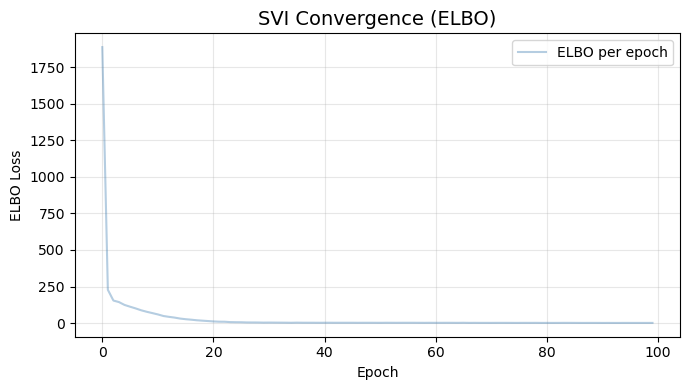

In [20]:
# plot ELBO loss during training

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(history, color='steelblue', linewidth=1.5, alpha=0.4, label='ELBO per epoch')

ax.set_title('SVI Convergence (ELBO)', fontsize=14)
ax.set_xlabel('Epoch')
ax.set_ylabel('ELBO Loss')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### test

After having trained the model with the full training dataset, we evaluate it on the test set:

In [21]:
# predict
scaler = {"mean": test_ds.mean, "std": test_ds.std}
y_true, y_samples, y_mean, upper, lower = prediction_curve(esn_var, test_ds, scaler = scaler, num_samples = 1000, plot = False)

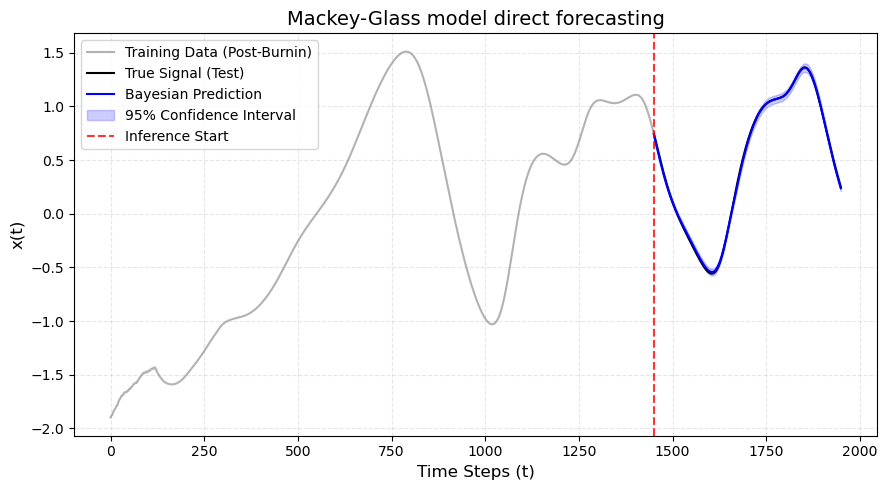

In [30]:
# extract train/test based on burnin steps
L = len(X)
num_samples = L - burnin
split_index = int(num_samples * final_split)

train_line = X[burnin : burnin + split_index].cpu().numpy()

test_line = y_true.cpu().numpy()
pred_line = y_mean.cpu().numpy()
lower_line = lower.cpu().numpy().flatten()
upper_line = upper.cpu().numpy().flatten()

# time axes
t_train = len(train_line)
t_test = len(test_line)

indices_train = np.arange(t_train)
indices_test = np.arange(t_train, t_train + t_test)


# PLOTS
plt.figure(figsize=(9, 5))

# Training Phase
plt.plot(indices_train, train_line, color='gray', label='Training Data (Post-Burnin)', alpha=0.6)

# Ground Truth
plt.plot(indices_test, test_line, color='black', label='True Signal (Test)', linewidth=1.5)

# Bayesian Mean Prediction
plt.plot(indices_test, pred_line, color='blue', label='Bayesian Prediction', linewidth=1.5)

# 95% Confidence Interval 
plt.fill_between(
    indices_test, 
    lower_line, 
    upper_line, 
    color='blue', 
    alpha=0.2, 
    label='95% Confidence Interval'
)

plt.axvline(x=t_train, color='red', linestyle='--', alpha=0.8, label='Inference Start')

plt.title("Mackey-Glass model direct forecasting", fontsize=14)
plt.xlabel("Time Steps (t)", fontsize=12)
plt.ylabel("x(t)", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()


From the plot we see that the Echo state network with SVI (used in directed forecasting mode) is able to reproduce the Mackey Glass time series.

In [23]:
# metrics
ecov, cal, mcrps = evaluate_metrics(y_samples, y_true)

# ranges for each region (used to normalize the mcrps)
ranges = y_true.max(dim=0).values - y_true.min(dim=0).values


# convert the vector of mrcps in a normalized avergae
n_mcrps = mcrps / ranges

avg_mcrps = n_mcrps.mean().item()

In [24]:
std_ecov = np.std(ecov.detach().numpy())/np.sqrt(len(ecov))
std_cal = np.std(cal.detach().numpy())/np.sqrt(len(cal))
std_mcrps = np.std(n_mcrps.detach().numpy())/np.sqrt(len(n_mcrps))


# Rounding to 4 decimal places for precision, or change .4f to .3f for 3 places
print(f"Empirical Coverage: {ecov.mean().item():.7f}")
print(f"Calibration Error:  {cal.mean().item():.7f}")
print(f"mCRPS (Normalized): {avg_mcrps:.7f}")

Empirical Coverage: 0.9980000
Calibration Error:  0.0146100
mCRPS (Normalized): 0.0035097


The model is slightly overconservative in its uncertainty estimates, producing prediction intervals wider than necessary (empirical coverage = 1.0 vs nominal 0.95). However, calibration error and mCRPS remain low, indicating overall good probabilistic performance.

### Recursive forecasting

In this section we try to forecast the value of the time series at time t+1 given the prediction at time t. In order to help the model, we first give as input "start_at_steps" real samples to increase stability.

In [25]:
# Run the inference
y_rec_rescaled, y_upper, y_lower, y_samples = recursive_inference(esn_var, test_ds, total_steps = 100, start_at_step=50, num_samples=1000)


Step 50
Step 60
Step 70
Step 80
Step 90


In [26]:
# Un-scale
y_true_abs = test_ds.predictions  
y_pred_abs = (y_rec_rescaled * test_ds.std) + test_ds.mean
y_samples_scaled = (y_samples * test_ds.std) + test_ds.mean
y_upper_scaled = (y_upper * test_ds.std) + test_ds.mean
y_lower_scaled = (y_lower * test_ds.std) + test_ds.mean

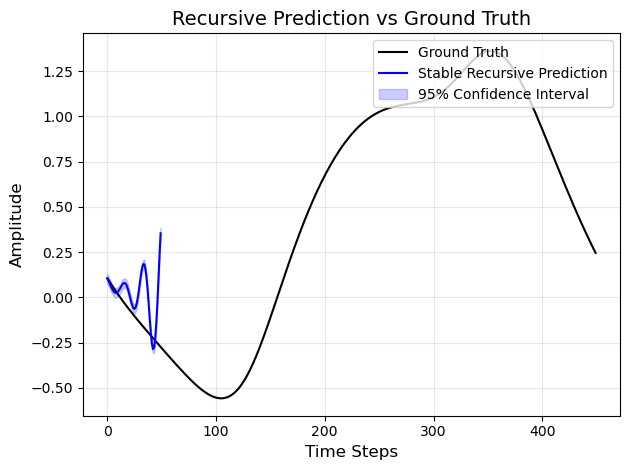

In [27]:
# Plot
plt.plot(y_true_abs[50:], color='black', label='Ground Truth')
plt.plot(y_pred_abs, color='blue', label='Stable Recursive Prediction')

plt.fill_between(
    range(len(y_pred_abs)), 
    y_lower_scaled.squeeze(1), 
    y_upper_scaled.squeeze(1), 
    color='blue', 
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("Recursive Prediction vs Ground Truth", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The recursive forecasting performance degrades rapidly due to the chaotic nature of the Mackey-Glass system. The positive Lyapunov exponent causes prediction errors to amplify exponentially at each step, making long-horizon autonomous forecasting fundamentally limited regardless of model quality. This is consistent with the theoretical properties of the system and should not be interpreted as a failure of the model.